<a href="https://colab.research.google.com/github/Vitoriinoo/FIAP_Machine_Learning/blob/main/ATIVIDADE_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint: Classificação com KNN (K-Nearest Neighbors)
**Objetivo da Atividade:** Importar o dataset Iris, aplicar a padronização correta nos dados, testar o algoritmo variando o número de vizinhos ($K$) de 1 a 20, exibir os resultados em uma tabela e avaliar o melhor modelo usando a Matriz de Confusão.

In [1]:
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 2. CARREGAMENTO DOS DADOS
iris = load_iris()
X = iris.data    # As características (features)
y = iris.target  # O alvo (espécies)
especies_pt = ['setosa', 'versicolor', 'virginica'] # Tradução para os gráficos

print("Bibliotecas importadas e dados carregados com sucesso!")

Bibliotecas importadas e dados carregados com sucesso!


## Padronização e Divisão dos Dados (A Regra de Ouro)
Como o KNN calcula distâncias, **padronizar os dados é essencial**. Para que as medidas tenham os mesmos formatos

In [3]:
# 1. Divisão dos dados (80% para treino, 20% para teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_treino_padronizado = scaler.fit_transform(X_treino)

X_teste_padronizado = scaler.transform(X_teste)

print("Dados divididos e padronizados corretamente!")

Dados divididos e padronizados corretamente!


## Testando Valores de K (1 a 20)
Agora vamos treinar o modelo 20 vezes, variando o número de vizinhos de 1 a 20, para descobrir qual configuração entrega a melhor acurácia no conjunto de teste.

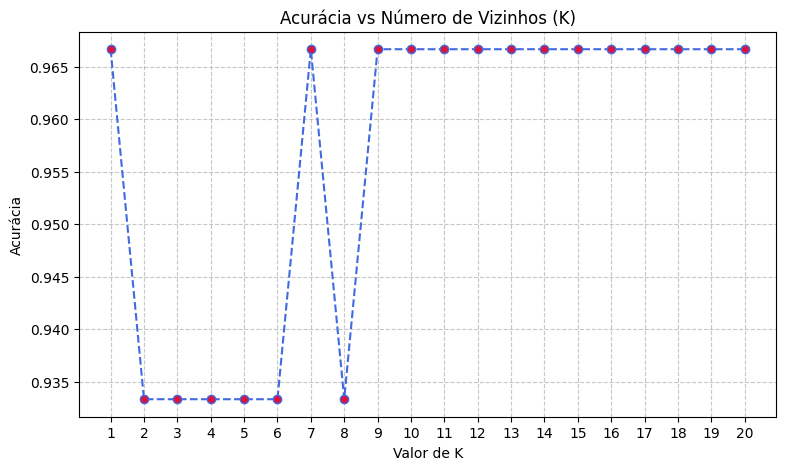

In [4]:
valores_k = range(1, 21)
acuracias = []

# Loop para testar cada K
for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_treino_padronizado, y_treino)

    y_previsto = knn.predict(X_teste_padronizado)
    acuracias.append(accuracy_score(y_teste, y_previsto))

# Lógica para encontrar o melhor K (Evitando K=1 para não gerar Overfitting)
acuracia_maxima = max(acuracias)
ks_empatados = [valores_k[i] for i, nota in enumerate(acuracias) if nota == acuracia_maxima]

if 1 in ks_empatados and len(ks_empatados) > 1:
    ks_empatados.remove(1)

melhor_k = min(ks_empatados)

# Plotando o Gráfico Visual
plt.figure(figsize=(9, 5))
plt.plot(valores_k, acuracias, marker='o', linestyle='dashed', color='royalblue', markerfacecolor='crimson')
plt.title('Acurácia vs Número de Vizinhos (K)')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Tabela de Resultados
Consolidando os testes para visualizar de forma clara quais foram os melhores valores de $K$.

In [5]:
# Criando a tabela (DataFrame) com os resultados
df_resultados = pd.DataFrame({
    'Valor de K': valores_k,
    'Acurácia': acuracias
})

# Ordenando da maior acurácia para a menor
df_resultados_ordenados = df_resultados.sort_values(by='Acurácia', ascending=False).reset_index(drop=True)
df_resultados_ordenados['Acurácia'] = df_resultados_ordenados['Acurácia'].apply(lambda x: f"{x:.4f}")

print("🏆 Top 5 Melhores Configurações:")
display(df_resultados_ordenados.head(5))
print(f"\n=> O valor escolhido como mais seguro e eficiente foi K = {melhor_k}.")

🏆 Top 5 Melhores Configurações:


,Valor de K,Acurácia
0,1,0.9667
1,10,0.9667
2,11,0.9667
3,7,0.9667
4,17,0.9667



=> O valor escolhido como mais seguro e eficiente foi K = 7.


## Avaliação Final e Matriz de Confusão
Utilizando o melhor modelo ($K$ escolhido), vamos analisar onde o algoritmo acertou e onde ele se confundiu, verificando o desempenho por espécie.

--- Desempenho do Modelo Final (K=7) ---

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



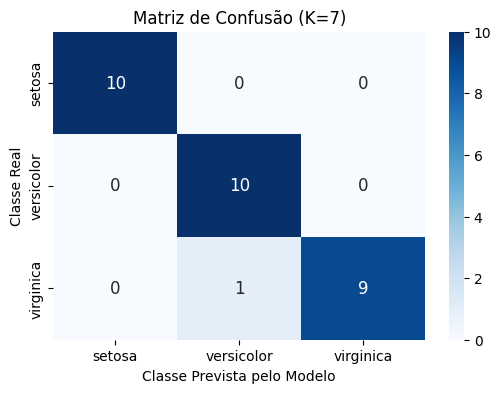

In [6]:
print(f"--- Desempenho do Modelo Final (K={melhor_k}) ---\n")

# Treinando o modelo definitivo
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_treino_padronizado, y_treino)
y_previsto_final = knn_final.predict(X_teste_padronizado)

# Exibindo o Relatório de Classificação
print(classification_report(y_teste, y_previsto_final, target_names=especies_pt))

# Gerando a Matriz de Confusão
cm = confusion_matrix(y_teste, y_previsto_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=especies_pt, yticklabels=especies_pt, annot_kws={"size": 12})

plt.title(f'Matriz de Confusão (K={melhor_k})')
plt.xlabel('Classe Prevista pelo Modelo')
plt.ylabel('Classe Real')
plt.show()

**CONCLUSÃO**

O trabalho realizado utilizando o KNN (conceito dos vizinhos mais próximos) foi extremamente interessante. Seguimos os passos ensinados pelo professor (importação de bibliotecas, padronização de dados, etc.). Desta maneira, conseguimos desenvolver um sistema usando o KNN com uma acurácia elevada, como pode ser visto na matriz de confusão apresentada no final.

A ideia de "treinar" com o K in range foi algo que nos auxiliou bastante, pois dessa maneira pudemos analisar com mais rigor e descobrimos que o K = 7 é o ideal. Foi uma atividade enriquecedora, pois colocamos em prática conceitos que antes não havíamos entendido 100%. Sem dúvida alguma, foi algo excelente para nosso desenvolvimento profissional.

